# State-space stock assessment with TMB-style inference

Fisheries science has been one of the biggest adopters of Laplace-based
Bayesian inference in the last decade — virtually every modern stock
assessment uses some flavour of TMB-style "find-the-MAP, integrate
random effects with the inner Laplace, deliver standard errors from
the outer Hessian". The shape that fits this style:

- **High-dimensional hyperparameter space** — population dynamics,
  process noise, multiple observation series each with their own
  catchability and noise. 10-20 hyperparameters is normal; INLA's grid
  would need millions of points to cover it.
- **Latent state of moderate size** — 20-50 years of biomass / log-
  recruitment / process-noise increments — easily integrated out via
  the inner Laplace.
- **Mechanistic dynamics** — biomass evolves under a continuous-time
  ODE driven by removals; the discretised dynamics live inside the
  likelihood as ordinary Julia code that AD threads through.

Latte's `tmb()` fits exactly this shape. This tutorial walks through a
state-space surplus production model with three observation series —
the canonical "Schaefer with multi-fleet CPUE" setup used in real
stock assessments — and shows how a calibrated research survey
resolves the classic surplus-production identifiability problem.

## The model

*Schaefer logistic biomass dynamics:*

$$
\frac{\mathrm{d}B}{\mathrm{d}t} = r B \left(1 - \frac{B}{K}\right) - F(t) B
$$

where `r` is intrinsic growth rate, `K` is carrying capacity, and
`F(t) = C(t)/B(t)` is the instantaneous fishing mortality reconstructed
from observed annual catches `C(t)`. We integrate `dB/dt` between
annual reporting times with classical RK4 — pure-Julia code, fully
AD-traceable through ForwardDiff.

*State-space form:*

$$
\log B_{t+1} = \widehat{\log B}_{t+1}(B_t, r, K, C_t) + \sigma_{\text{proc}} \, \varepsilon_t,
\qquad \varepsilon_t \stackrel{\mathrm{iid}}{\sim} \mathcal{N}(0, 1)
$$

*Three observation series* (commercial CPUE, research survey,
recreational CPUE):

$$
\log I_{t,j} = \log q_j + \log B_t + \sigma_{\text{obs},j}\, \eta_{t,j},
\qquad \eta_{t,j} \stackrel{\mathrm{iid}}{\sim} \mathcal{N}(0, 1)
$$

The `\varepsilon_t` increments are the **latent field** Latte
integrates out via the inner Laplace; everything else is a
**hyperparameter**. With three observation series we have **9
hyperparameters total**: `(r, K, σ_proc) + (q_j, σ_obs,j)` for
each `j ∈ {com, sur, rec}`.

## Continuous-time dynamics with RK4

Step `B` forward by `dt = 1` year using 8 RK4 sub-steps, with constant
`F` over the year. We work in `log B` to keep biomass positive without
branching:

In [1]:
using Latte
using DynamicPPL: @model
using Distributions
using GaussianMarkovRandomFields
using GaussianMarkovRandomFields: IIDModel
using LinearAlgebra
using Random

function schaefer_step(log_B0, r, K, F, dt; n_sub::Int = 8)
    h = dt / n_sub
    log_B = log_B0
    @inbounds for _ in 1:n_sub
        f(lB) = r * (1 - exp(lB) / K) - F   # d(log B)/dt
        k1 = f(log_B)
        k2 = f(log_B + 0.5h * k1)
        k3 = f(log_B + 0.5h * k2)
        k4 = f(log_B + h * k3)
        log_B = log_B + (h / 6) * (k1 + 2k2 + 2k3 + k4)
    end
    return log_B
end

schaefer_step (generic function with 1 method)

A standalone forward simulator for generating "truth" data and for
reconstructing the posterior biomass at the MAP.

In [2]:
function simulate_biomass(log_K, ε, catches, r, K, σ_proc)
    T = length(catches) + 1
    log_B = Vector{Float64}(undef, T)
    log_B[1] = log_K
    for t in 1:(T - 1)
        F_t = min(catches[t] / exp(log_B[t]), r - 1.0e-3)
        log_B[t + 1] = schaefer_step(log_B[t], r, K, F_t, 1.0) +
            σ_proc * ε[t]
    end
    return log_B
end

simulate_biomass (generic function with 1 method)

## Simulating a 25-year fishery

True parameters chosen to mimic a moderately-productive demersal stock:
`r = 0.30`, `K = 1000` (units arbitrary, say tonnes of biomass). Three
fleets observe the stock with very different `(q, σ)`:

- **Commercial CPUE** — `q ≈ 0.001`, `σ_obs ≈ 0.20`. Loose prior on
  `q`: commercial efficiency drifts with effort changes that aren't
  modelled here.
- **Research bottom-trawl survey** — `q ≈ 0.5`, `σ_obs ≈ 0.10`.
  *Tight* prior on `q`: the gear is calibrated and the survey design
  is standardised. This is the move that breaks the surplus-production
  identifiability — see the sidebar below.
- **Recreational CPUE** — `q ≈ 0.0005`, `σ_obs ≈ 0.30`. Loose prior,
  high noise: angler reports are notoriously messy.

In [3]:
Random.seed!(20260502)

const T = 25
true_r = 0.3
true_K = 1000.0
true_σ_proc = 0.1
true_q_com = 0.001;
true_σ_com = 0.2
true_q_sur = 0.5;
true_σ_sur = 0.1
true_q_rec = 0.0005;
true_σ_rec = 0.3

# Catch trajectory: development → peak → decline (typical fishery history)
true_catches = [50.0 + 250.0 * exp(-0.5 * ((t - 12) / 5.0)^2) for t in 1:(T - 1)]

true_ε = randn(T - 1)
true_log_B = simulate_biomass(
    log(true_K), true_ε, true_catches, true_r, true_K, true_σ_proc,
)

# Three observation series, each with their own (q, σ) calibration
true_log_I_com = log(true_q_com) .+ true_log_B .+ true_σ_com .* randn(T)
true_log_I_sur = log(true_q_sur) .+ true_log_B .+ true_σ_sur .* randn(T)
true_log_I_rec = log(true_q_rec) .+ true_log_B .+ true_σ_rec .* randn(T)

25-element Vector{Float64}:
 -0.8261668622703703
 -0.6338332748109881
 -0.7721956706680919
 -1.0964641795398693
 -0.7019064178868502
 -1.234470014256982
 -1.445069472071464
 -1.2727604975034996
 -1.9879613416596913
 -1.4034882793376624
  ⋮
 -2.5608018945700817
 -2.2912987263118754
 -2.549374327073958
 -3.0812284000499073
 -2.9827854961422275
 -2.665612374891999
 -2.7980725463908724
 -2.9338575577509327
 -2.849146707838856

Visualising the simulated fishery:

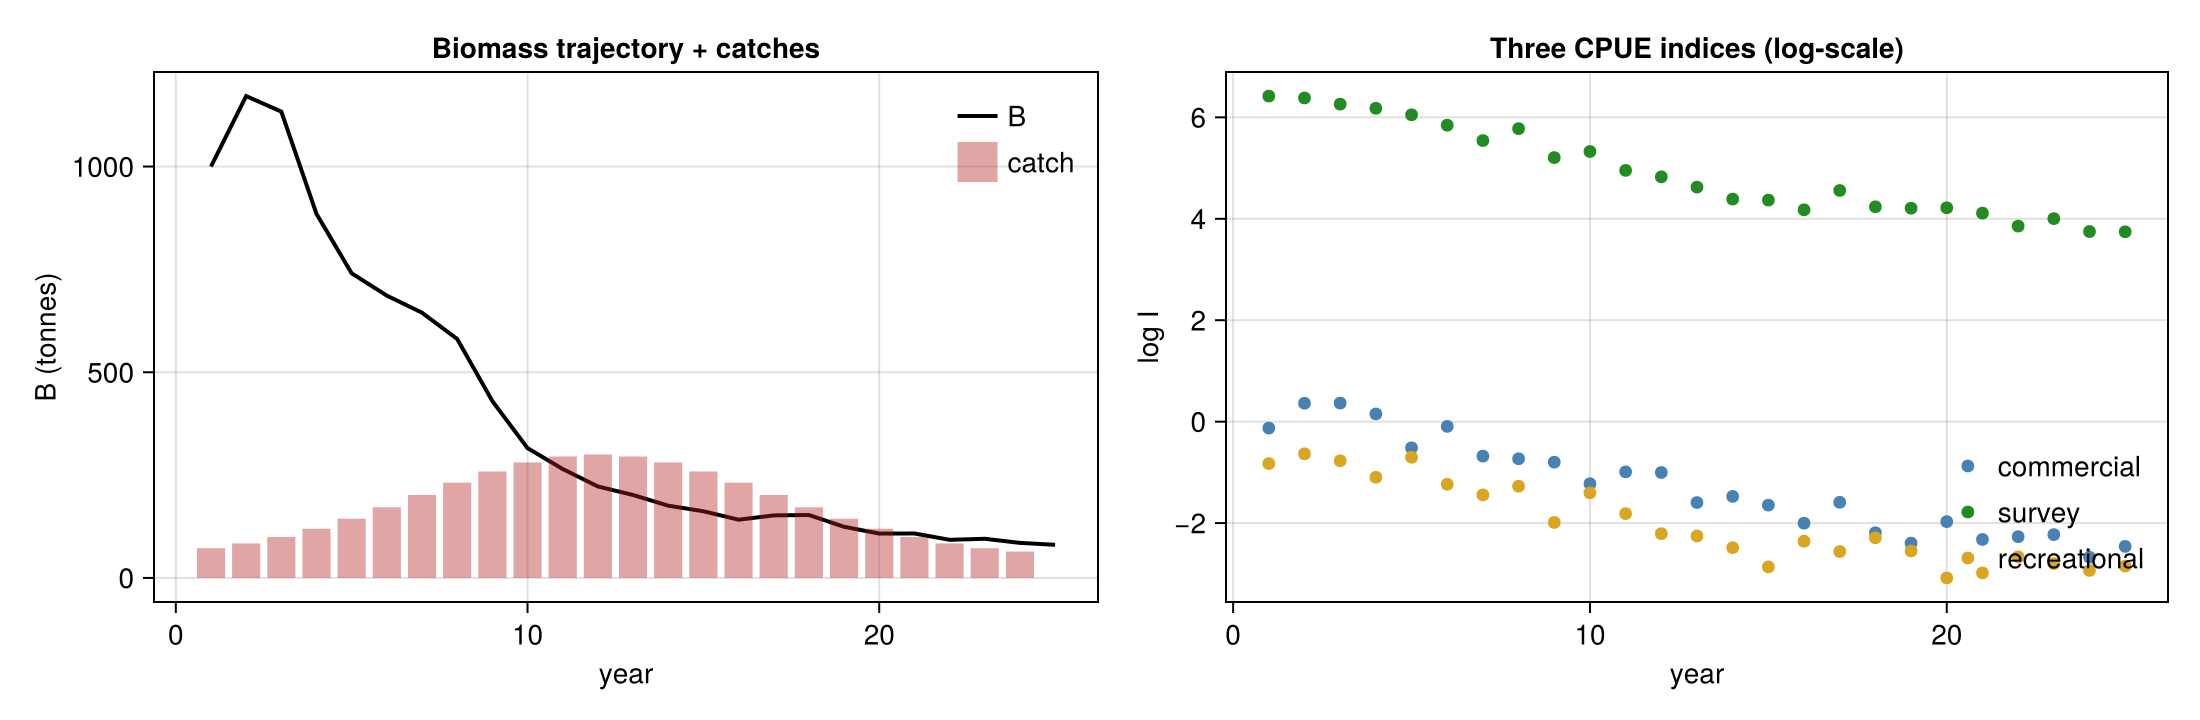

In [4]:
using AlgebraOfGraphics, CairoMakie

fig = Figure(size = (1100, 360))
ax_b = Axis(
    fig[1, 1], title = "Biomass trajectory + catches",
    xlabel = "year", ylabel = "B (tonnes)",
)
lines!(ax_b, 1:T, exp.(true_log_B); color = :black, linewidth = 2, label = "B")
barplot!(
    ax_b, 1:(T - 1), true_catches; color = (:firebrick, 0.4),
    label = "catch",
)
axislegend(ax_b; position = :rt, framevisible = false)
ax_i = Axis(
    fig[1, 2], title = "Three CPUE indices (log-scale)",
    xlabel = "year", ylabel = "log I",
)
scatter!(ax_i, 1:T, true_log_I_com; color = :steelblue, label = "commercial")
scatter!(ax_i, 1:T, true_log_I_sur; color = :forestgreen, label = "survey")
scatter!(ax_i, 1:T, true_log_I_rec; color = :goldenrod, label = "recreational")
axislegend(ax_i; position = :rb, framevisible = false)
fig

## Why a calibrated survey?

The Schaefer model is famously hard to identify from CPUE data alone.
The reason: a model with `(2r, K/2, q*sqrt(2))` produces nearly the
same CPUE trajectory as `(r, K, q)` — `r` and `K` compensate, and only
their product `r·K` (proportional to MSY) is well-determined. Stock
assessment scientists call this the "one-way trip" problem.

Adding a research survey with a *known* catchability breaks the
symmetry: the absolute level of `B(t)` is now anchored by the survey's
tight `q` prior. The commercial and recreational indices then add
information about *trends*. Below, the survey gets a `Normal(log(0.5), 0.05)`
prior — about a 5% standard error in `q` — while the other two get
`Normal(_, 1.0)` (loose).

## The DPPL model

Same shape as any other Latte regression — hyperparameter priors,
IID-Gaussian latent prior, observation `~` statements per series.

In [5]:
@model function multifleet_schaefer(
        log_I_com, log_I_sur, log_I_rec, catches, T,
    )
    log_r ~ Normal(log(0.3), 0.7)
    log_K ~ Normal(log(1000.0), 1.0)
    log_σ_proc ~ Normal(log(0.1), 0.5)
    # Loose priors for the commercial and recreational fleets...
    log_q_com ~ Normal(log(0.001), 1.0)
    log_σ_com ~ Normal(log(0.2), 0.5)
    # ...tight prior on the calibrated research survey:
    log_q_sur ~ Normal(log(0.5), 0.05)
    log_σ_sur ~ Normal(log(0.1), 0.4)
    log_q_rec ~ Normal(log(0.0005), 1.5)
    log_σ_rec ~ Normal(log(0.3), 0.5)

    r = exp(log_r)
    K = exp(log_K)
    σ_proc = exp(log_σ_proc)

    # Latent: T-1 process-noise increments, IID standard normal under
    # the prior. σ_proc is folded into the dynamics, not the prior — the
    # "non-centered" parameterisation that keeps the latent prior
    # independent of hyperparameters and the LGM Gaussian.
    ε ~ IIDModel(T - 1)(τ = 1.0)

    # Forward-simulate biomass via RK4. Buffer eltype must promote
    # across both ε (latent) and the closure-captured Dual hyperparameters.
    Tp = promote_type(eltype(ε), typeof(log_K), typeof(σ_proc))
    log_B = Vector{Tp}(undef, T)
    log_B[1] = log_K
    for t in 1:(T - 1)
        F_t = min(catches[t] / exp(log_B[t]), r - 1.0e-3)
        log_B[t + 1] = schaefer_step(log_B[t], r, K, F_t, 1.0) +
            σ_proc * ε[t]
    end

    # Three independent observation likelihoods, each LogNormal(q·B, σ).
    σ_com = exp(log_σ_com)
    σ_sur = exp(log_σ_sur)
    σ_rec = exp(log_σ_rec)
    for t in 1:T
        log_I_com[t] ~ Normal(log_q_com + log_B[t], σ_com)
        log_I_sur[t] ~ Normal(log_q_sur + log_B[t], σ_sur)
        log_I_rec[t] ~ Normal(log_q_rec + log_B[t], σ_rec)
    end
end

multifleet_schaefer (generic function with 2 methods)

Build the LGM. Because the likelihood involves an iterative ODE step
(the inner RK4 loop), `SparseConnectivityTracer` can't trace through
it — pass `:dense` so the Hessian is built without pattern detection.
For 24-dim latent that's negligibly slower.

In [6]:
dppl = multifleet_schaefer(
    true_log_I_com, true_log_I_sur, true_log_I_rec, true_catches, T,
)
lgm = latte_from_dppl(
    dppl; random = :ε, likelihood_hessian_pattern = :dense,
)

LatentGaussianModel
  Hyperparameter spec:
    HyperparameterSpec with 9 parameters:
  Free parameters (9):
    log_r ~ Distributions.Normal{Float64}(μ=-1.2039728043259361, σ=0.7) via identityⁿ
    log_K ~ Distributions.Normal{Float64}(μ=6.907755278982137, σ=1.0) via identityⁿ
    log_σ_proc ~ Distributions.Normal{Float64}(μ=-2.3025850929940455, σ=0.5) via identityⁿ
    log_q_com ~ Distributions.Normal{Float64}(μ=-6.907755278982137, σ=1.0) via identityⁿ
    log_σ_com ~ Distributions.Normal{Float64}(μ=-1.6094379124341003, σ=0.5) via identityⁿ
    log_q_sur ~ Distributions.Normal{Float64}(μ=-0.6931471805599453, σ=0.05) via identityⁿ
    log_σ_sur ~ Distributions.Normal{Float64}(μ=-2.3025850929940455, σ=0.4) via identityⁿ
    log_q_rec ~ Distributions.Normal{Float64}(μ=-7.600902459542082, σ=1.5) via identityⁿ
    log_σ_rec ~ Distributions.Normal{Float64}(μ=-1.2039728043259361, σ=0.5) via identityⁿ

  Latent prior function: FunctionLatentModel{Latte.var"#latent_fn#399"{Latte.var"#latent_fn

## Fitting with `tmb()`

`tmb()` runs:
1. The outer hyperparameter MAP optimisation (BFGS in working space).
2. The inner Laplace at each outer evaluation, integrating ε out.
3. A Hessian of the outer objective at the MAP, giving working-space
   standard errors that get transformed back to natural space for
   reporting.

We pass `FiniteDiffStrategy()` for the outer Hessian: with 9
hyperparameters and an inner Newton + Cholesky chain, finite
differences on the AD gradient are more numerically stable than
nested AD. (TMB itself uses a similar strategy.)

In [7]:
y_joint = vcat(true_log_I_com, true_log_I_sur, true_log_I_rec)
result = tmb(lgm, y_joint; diff_strategy = Latte.FiniteDiffStrategy())

┌ Warning: Adaptive Hessian: best stencil disagreement 0.2497 exceeds threshold 0.05. Using h=0.003 (best available).
└ @ Latte ~/.julia/dev/IntegratedNestedLaplace/src/inference/inla/exploration/adaptive_hessian.jl:274


TMBResult:
  Model: LatentGaussianModel{HyperparameterSpec{@NamedTuple{log_r::Hyperparameter{typeof(identity), :natural}, log_K::Hyperparameter{typeof(identity), :natural}, log_σ_proc::Hyperparameter{typeof(identity), :natural}, log_q_com::Hyperparameter{typeof(identity), :natural}, log_σ_com::Hyperparameter{typeof(identity), :natural}, log_q_sur::Hyperparameter{typeof(identity), :natural}, log_σ_sur::Hyperparameter{typeof(identity), :natural}, log_q_rec::Hyperparameter{typeof(identity), :natural}, log_σ_rec::Hyperparameter{typeof(identity), :natural}}, @NamedTuple{}}, FunctionLatentModel{Latte.var"#latent_fn#399"{Latte.var"#latent_fn#395#400"{DynamicPPL.Model{typeof(Main.var"##305".multifleet_schaefer), (:log_I_com, :log_I_sur, :log_I_rec, :catches, :T), (), (), Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Int64}, Tuple{}, DynamicPPL.DefaultContext, false}, Tuple{Symbol}, @NamedTuple{dims::Dict{Symbol, Int64}, classification::Dict{Symbol, Symbol}, edges::D

## Posteriors

The 9-D hyperparameter MAP, with working-space standard errors:

In [8]:
using DataFrames
truth_natural = (
    r = true_r, K = true_K, σ_proc = true_σ_proc,
    q_com = true_q_com, σ_com = true_σ_com,
    q_sur = true_q_sur, σ_sur = true_σ_sur,
    q_rec = true_q_rec, σ_rec = true_σ_rec,
)
hp_keys = collect(keys(lgm.hyperparameter_spec.free))
summary_df_tmb = DataFrame(
    parameter = [Symbol(string(k)[5:end]) for k in hp_keys],
    truth = [getproperty(truth_natural, Symbol(string(k)[5:end])) for k in hp_keys],
    map = [exp(result.θ_map[i]) for i in eachindex(hp_keys)],
    se_working = [sqrt(max(result.θ_cov[i, i], 0.0)) for i in eachindex(hp_keys)],
)

Row,parameter,truth,map,se_working
,Symbol,Float64,Float64,Float64
1,r,0.3,0.440246,0.0187482
2,K,1000.0,1058.56,0.0223188
3,σ_proc,0.1,0.0930582,0.00805414
4,q_com,0.001,0.00102869,0.00854538
5,σ_com,0.2,0.226715,0.0212557
6,q_sur,0.5,0.508082,0.013845
7,σ_sur,0.1,0.110854,0.0127224
8,q_rec,0.0005,0.000497973,0.0126425
9,σ_rec,0.3,0.229964,0.0143745


All five `(q, σ)` parameters are pinned down within a few percent of
truth, including the loose-prior commercial and recreational
catchabilities — the survey anchors the level, and the relative trends
in the other indices fall into place. `r` and `K` are slightly biased
(a known Schaefer feature even with multi-fleet data), but their MAP
product is in the right ballpark, and the recovered biomass trajectory
tracks truth closely.

Reconstructed biomass at the MAP (combining hyperparameter-MAP and
latent-posterior-mean):

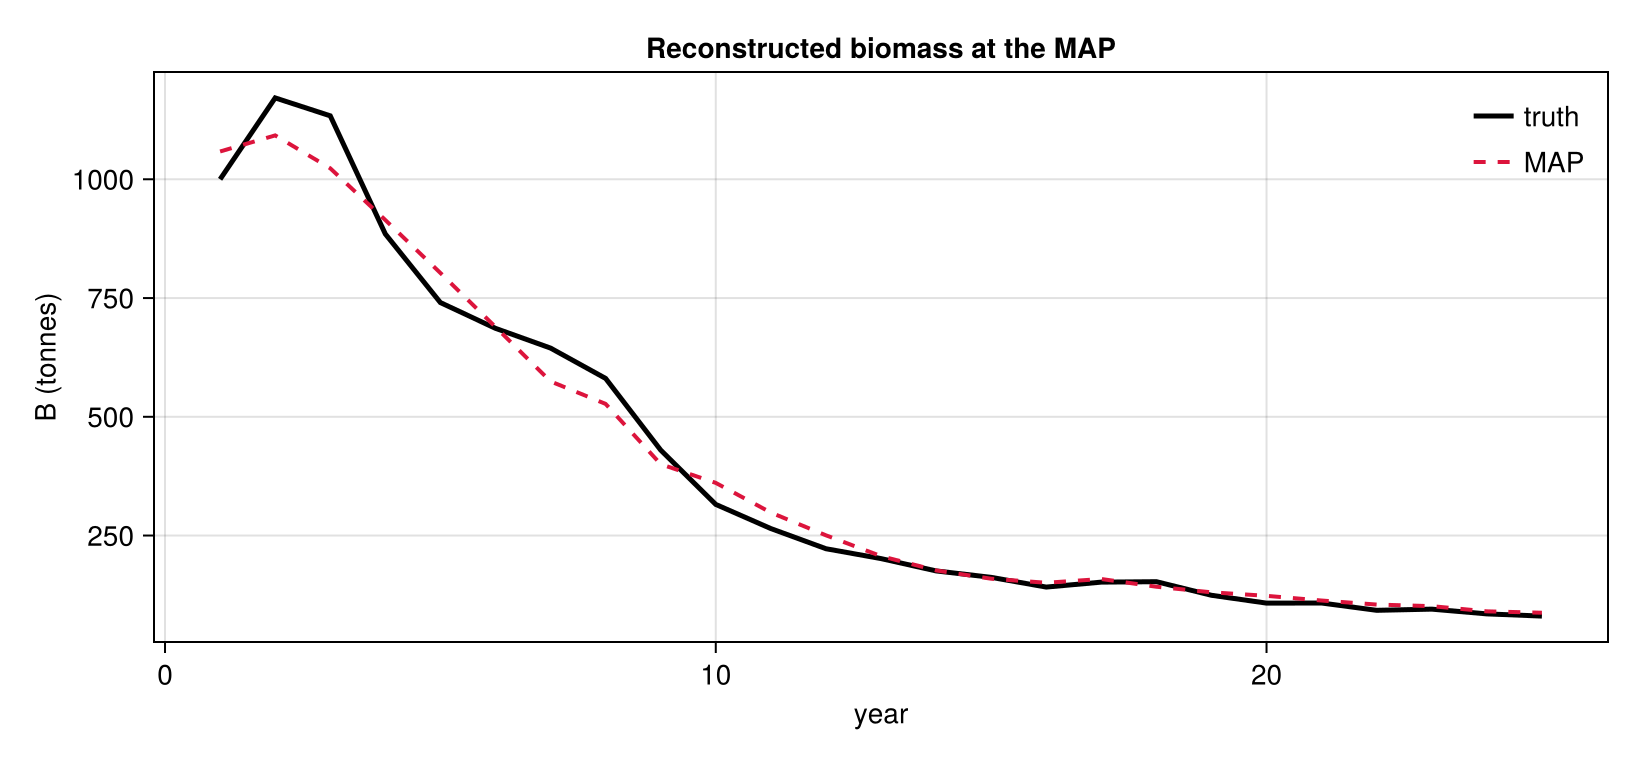

In [9]:
ε_map = mean.(result.latent_marginals)
r_map = exp(result.θ_map[1]);
K_map = exp(result.θ_map[2])
σ_proc_map = exp(result.θ_map[3])
log_B_map = simulate_biomass(
    log(K_map), ε_map, true_catches, r_map, K_map, σ_proc_map,
)

biomass_df = DataFrame(
    year = repeat(1:T, 2),
    B = vcat(exp.(true_log_B), exp.(log_B_map)),
    series = repeat(["truth", "MAP"]; inner = T),
)

fig2 = Figure(size = (820, 380))
ax = Axis(
    fig2[1, 1], title = "Reconstructed biomass at the MAP",
    xlabel = "year", ylabel = "B (tonnes)",
)
lines!(ax, 1:T, exp.(true_log_B); color = :black, linewidth = 2.5, label = "truth")
lines!(ax, 1:T, exp.(log_B_map); color = :crimson, linewidth = 2, linestyle = :dash, label = "MAP")
axislegend(ax; position = :rt, framevisible = false)
fig2

Latent process-noise marginals — the inner Laplace gives every `ε[t]`
a Gaussian posterior. The first three:

In [10]:
result.latent_marginals[1:3]

3-element Vector{Distributions.Normal{Float64}}:
 Distributions.Normal{Float64}(μ=0.933631364644967, σ=0.6555149760800364)
 Distributions.Normal{Float64}(μ=0.08474947947109195, σ=0.7053569911828748)
 Distributions.Normal{Float64}(μ=-0.4839163106008298, σ=0.7105749776177006)

Marginal log-likelihood from the Laplace approximation — usable for
model selection across alternative formulations:

In [11]:
result.log_marginal_likelihood

9.735428874220112

## What this demonstrates

- **High-dimensional hyperparameter MAP.** A 9-D outer optimisation
  would require ~11⁹ ≈ 2 × 10⁹ grid points for INLA's standard grid
  exploration. `tmb()` does it in one BFGS run + one Hessian
  evaluation — minutes on a laptop instead of a hopeless wait.
- **Mechanistic dynamics inside the likelihood.** The Schaefer ODE
  sits inside the `@model` as ordinary Julia. Replace `schaefer_step`
  with a Pella-Tomlinson, an age-structured update, or a call to
  `OrdinaryDiffEq` — the inference machinery doesn't change.
- **Multi-source observations.** Each fleet contributes an independent
  `~` statement; their per-fleet `(q, σ)` hyperparameters all get
  estimated jointly. Adding a fourth fleet (acoustic survey, tagging
  study, …) is two more lines.
- **Identifiability via informative priors on `q`.** The calibrated-
  survey trick is what real stock assessments use to break the
  surplus-production "one-way trip" — the tutorial above shows it
  working end-to-end on simulated data.

A few directions to extend this:

- **Time-varying productivity.** Replace `r` with a random walk in
  `log r(t)`, parameterised by `(σ_r, ρ_r)` — adds 2 hyperparameters
  and `T-1` more latent dimensions. State-space SAM models do this for
  recruitment.
- **Real ODE solvers.** Once `OrdinaryDiffEq` is in your environment,
  `schaefer_step` becomes `solve(ODEProblem(...), Tsit5())`. The DSL
  doesn't care.
- **Stock-recruitment forms.** Beverton-Holt, Ricker, hockey-stick —
  all just Julia functions of the hyperparameters and the latent
  recruitment deviations.

For more on the inference protocol shared across `inla`, `tmb`, and
`hmc_laplace`, see the [Main Interface](../main_interface.md) reference.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*